In [134]:
import sklearn
import pandas as pd
import numpy as np

In [145]:
# Setting Attrition as the target column
target_col = 'Attrition'

# Import the train and test datasets
df_train = pd.read_csv('data/cons_train_10.csv')
df_test = pd.read_csv('data/cons_test_10.csv')


In [147]:
# Renaming variables by defining the old and new column names as a dictionary
column_rename_dict = {
    "Drive_time_to_nearest_grocery_s": "Drive Time to Nearest Grocery Store",
    "Black_or_african_american": "Black or African American",
    "F__Grocery_Stores_in_10_min_dri": "Number of Grocery Stores in a 10 minute drive",
    "Drive_time_to_nearest_hospital_": "Drive Time to Nearest Hospital",
    "SVI_Score": "Social Vulnerability Index (SVI) Score",
    "MCS": "Mental Component Score (MCS)",
    "PCS": "Physical Component Score (PCS)",
    "Self_Efficacy_for_Diabetes": "Self Efficacy for Diabetes",
    "Exercise_Subscale": "Exercise Subscale",
    "Blood_Glucose_Testing_Subscale": "Blood Glucose Testing Subscale",
    "DCI_Score": "Distressed Communities Index (DCI) Score",
    "Specific_Diet_Subscale": "Specific Diet Subscale",
    "Foot_Care_Subscale": "Foot Care Subscale",
    "General_Diet_Subscale": "General Diet Subscale",
    "Sex": "Sex",
    "White": "White",
    "Diabetes_Knowledge_Score": "Diabetes Knowledge Score",
    "Specific_Diet_Subscle": "Specific Diet Subscale"
}


# Rename the columns
df_train.rename(columns=column_rename_dict, inplace=True)
df_test.rename(columns=column_rename_dict, inplace=True)

In [149]:
# get data matrices and target vectors

# train
X_train = df_train.drop(target_col, axis=1)
y_train = df_train[target_col]

# test
X_test = df_test.drop(target_col, axis=1)
y_test = df_test[target_col]

## Logistic Regression

In [216]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid
param_grid = {'C': np.logspace(-15, 1, 40)}

# Create an instance of the logistic regression model
logreg = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=10000)

# Create an instance of GridSearchCV
grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

# Fit the model to the training data
grid_search.fit(X_train, y_train)

# Get the Best estimator
best_model = grid_search.best_estimator_

# Get the best C value
best_C = grid_search.best_params_['C']

# Print the best C value
print("Best C value:", best_C)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best C value: 0.58780160722749


In [217]:
from sklearn.model_selection import cross_val_predict

# Get out-of-fold predicted probabilities for the positive class. 
y_train_pred_proba_cv = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

In [218]:
from sklearn.metrics import roc_curve

# Calculate ROC using the out-of-fold probabilities which allows us to calculate the optimal threshold without bias on the test data
fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_train, y_train_pred_proba_cv)

# Youden's J statistic
youden_j = tpr_cv - fpr_cv

# Find the optimal threshold using Youden's J statistic
optimal_threshold = thresholds_cv[np.argmax(youden_j)]
print(f"Optimal threshold from training CV: {optimal_threshold}")

Optimal threshold from training CV: 0.16871528838906047


In [219]:
# Refit the model using the best estimator
final_model = best_model.fit(X_train, y_train)

In [220]:
# Get predicted probabilities on the test set
y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Apply threshold from training CV
y_test_pred = (y_test_pred_proba > optimal_threshold).astype(int)

Accuracy: 0.5517241379310345
Sensitivity (Recall): 0.5333333333333333
Specificity: 0.5555555555555556
Precision: 0.2
Recall: 0.5333333333333333
F1 Score: 0.2909090909090909
ROC AUC: 0.5666666666666667


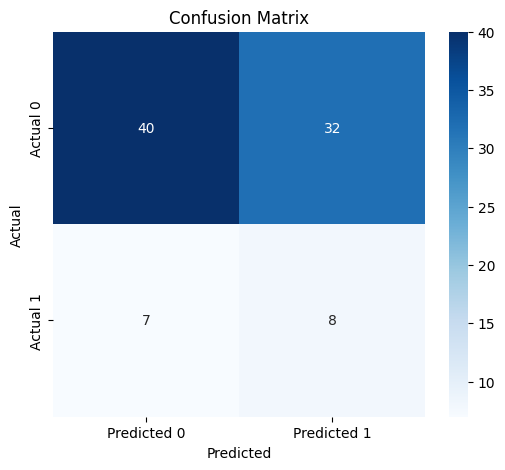

In [221]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Extracting True Positives, False Positives, True Negatives, False Negatives
tn, fp, fn, tp = cm.ravel()

# Compute Accuracy, Sensitivity, Specificity
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)  
specificity = tn / (tn + fp)

# Compute Precision
precision = tp / (tp + fp)

# Compute Recall 
recall = tp / (tp + fn)

# Compute F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_test_pred_proba)

# Print the results
print("Accuracy:", accuracy)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# define the grid
grid_space={'max_depth': [3, 4, 5, 6],
    'max_features': [4, 5, 6, 7],
    'min_samples_leaf': [1, 2, 3],
    'min_samples_split': [2, 3, 4]
}


# Define the parameter grid
param_grid = grid_space

# Create an instance of the random forest model
rf = RandomForestClassifier(n_estimators=2000, random_state=42)

# Create an instance of GridSearchCV
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

# Fit the model to the training data
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Get the best parameter values
best_parameters = grid_search.best_params_

# Get the best parameter AUC Score
best_score = grid_search.best_score_

# Print the best parameter values
print('Best hyperparameters are: '+str(best_parameters))
print('Best score is: '+str(best_score))

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best hyperparameters are: {'max_depth': 4, 'max_features': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score is: 0.5726869409660107


In [16]:
# Get out-of-fold predicted probabilities for the positive class
y_train_pred_proba_cv = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

In [17]:
# Calculate ROC
fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_train, y_train_pred_proba_cv)

# Youden's J statistic
youden_j = tpr_cv - fpr_cv

# Find the optimal threshold
optimal_threshold = thresholds_cv[np.argmax(youden_j)]
print(f"Optimal threshold from training CV: {optimal_threshold}")

Optimal threshold from training CV: 0.1490489730716377


In [18]:
final_model = best_model.fit(X_train, y_train)

In [19]:
# Get predicted probabilities on the test set
y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Apply threshold from training CV
y_test_pred = (y_test_pred_proba > optimal_threshold).astype(int)

F1 Score: 0.273972602739726
Accuracy: 0.39080459770114945
Sensitivity (Recall): 0.6666666666666666
Specificity: 0.3333333333333333
Precision: 0.1724137931034483
Recall: 0.6666666666666666
ROC AUC: 0.5305555555555556


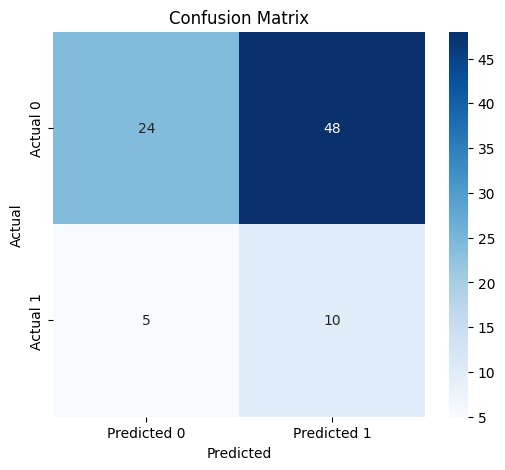

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Extracting True Positives, False Positives, True Negatives, False Negatives
tn, fp, fn, tp = cm.ravel()

# Compute Accuracy, Sensitivity, Specificity
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)  
specificity = tn / (tn + fp)

# Compute Precision
precision = tp / (tp + fp)

# Compute Recall 
recall = tp / (tp + fn)

# Compute F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("F1 Score:", f1)

# Print the results
print("Accuracy:", accuracy)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)
print("Precision:", precision)
print("Recall:", recall)
print("ROC AUC:", roc_auc)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## SMOTE Random Forest

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Creating a pipeline so SMOTE is applied properly during five-fold cross validation
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42))
])

# Define the parameter grid
param_grid = {
    'clf__n_estimators': [500],
    'clf__max_depth': [2, 5, 10, 22, 25, 27, 28,  30, 32, 35, 50],
    'clf__min_samples_split': [2, 3],
    'clf__min_samples_leaf': [1, 2, 3], 
    'clf__max_features': ['log2']

}


# Grid search using the pipeline
grid_search = GridSearchCV(pipeline, param_grid=param_grid, 
                           scoring='roc_auc', cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Get the best parameters and the best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f'Best Parameters: {best_params}')
print(f'Best AUC Score: {best_score}')

Fitting 5 folds for each of 66 candidates, totalling 330 fits
Best Parameters: {'clf__max_depth': 10, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 3, 'clf__n_estimators': 500}
Best AUC Score: 0.5735193798449613


In [ ]:
# Get out-of-fold predicted probabilities for the positive class
y_train_pred_proba_cv = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

In [23]:
# Calculate ROC
fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_train, y_train_pred_proba_cv)

# Youden's J statistic
youden_j = tpr_cv - fpr_cv

# Find the optimal threshold
optimal_threshold = thresholds_cv[np.argmax(youden_j)]
print(f"Optimal threshold from training CV: {optimal_threshold}")

Optimal threshold from training CV: 0.3608179462108621


In [24]:
final_model = best_model.fit(X_train, y_train)

In [25]:
# Get predicted probabilities on the test set
y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Apply threshold from training CV
y_test_pred = (y_test_pred_proba > optimal_threshold).astype(int)

F1 Score: 0.26086956521739135
Accuracy: 0.6091954022988506
Sensitivity: 0.4
Specificity: 0.6527777777777778
Precision: 0.1935483870967742
Recall: 0.4
ROC AUC: 0.5425925925925926


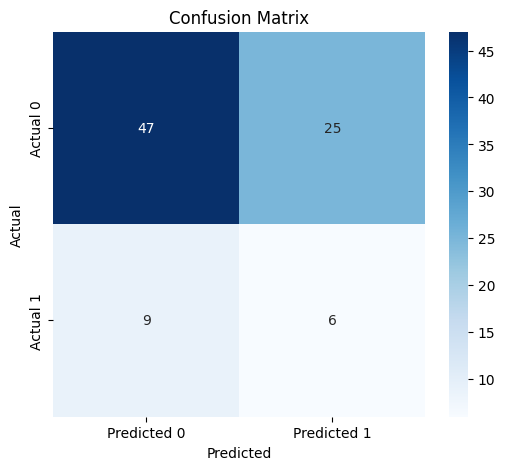

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Extracting True Positives, False Positives, True Negatives, False Negatives
tn, fp, fn, tp = cm.ravel()

# Compute Accuracy, Sensitivity, Specificity
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)  # Recall
specificity = tn / (tn + fp)

# Compute Precision
precision = tp / (tp + fp)

# Compute Recall 
recall = tp / (tp + fn)

# Compute F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("F1 Score:", f1)

# Print the results
print("Accuracy:", accuracy)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("Precision:", precision)
print("Recall:", recall)
print("ROC AUC:", roc_auc)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Cost Sensitive Random Forest

In [210]:
# Define the pipeline. class_weight = balanced allows us to balance the weights of the minority class with the majority class
pipeline = Pipeline([
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
])


# define the grid
grid_space={'clf__max_depth':[3,5,10,20, None],
              'clf__n_estimators':[1000],
              'clf__max_features':[1,3,5,7],
              'clf__min_samples_leaf':[1,2,3],
              'clf__min_samples_split':[2,3]
           }
# Define the parameter grid
param_grid = grid_space

# Create an instance of GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

# Fit the model to the training data
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Get the best parameter values
best_parameters = grid_search.best_params_

# Get the best parameter AUS Score
best_score = grid_search.best_score_

# Print the best parameter values
print('Best hyperparameters are: '+str(best_parameters))
print('Best score is: '+str(best_score))

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best hyperparameters are: {'clf__max_depth': 20, 'clf__max_features': 1, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 3, 'clf__n_estimators': 1000}
Best score is: 0.567200954084675


In [211]:
# Get out-of-fold predicted probabilities for the positive class
y_train_pred_proba_cv = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

In [212]:
# Calculate ROC
fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_train, y_train_pred_proba_cv)

# Youden's J statistic
youden_j = tpr_cv - fpr_cv

# Find the optimal threshold
optimal_threshold = thresholds_cv[np.argmax(youden_j)]
print(f"Optimal threshold from training CV: {optimal_threshold}")

Optimal threshold from training CV: 0.2197248171662705


In [213]:
# Refitting the model with the best estimator
final_model = best_model.fit(X_train, y_train)

In [214]:
# Get predicted probabilities on the test set
y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Apply threshold from training CV
y_test_pred = (y_test_pred_proba > optimal_threshold).astype(int)

F1 Score: 0.19047619047619047
Accuracy: 0.6091954022988506
Sensitivity (Recall): 0.26666666666666666
Specificity: 0.6805555555555556
Precision: 0.14814814814814814
Recall: 0.26666666666666666
ROC AUC: 0.5444444444444445


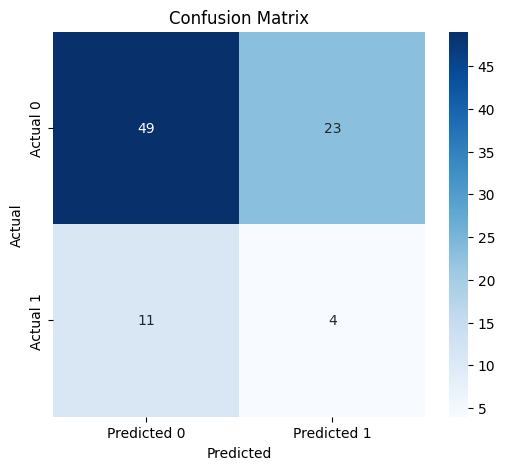

In [215]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Extracting True Positives, False Positives, True Negatives, False Negatives
tn, fp, fn, tp = cm.ravel()

# Compute Accuracy, Sensitivity, Specificity
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)  # Recall
specificity = tn / (tn + fp)

# Compute Precision
precision = tp / (tp + fp)

# Compute Recall 
recall = tp / (tp + fn)

# Compute F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("F1 Score:", f1)

# Print the results
print("Accuracy:", accuracy)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)
print("Precision:", precision)
print("Recall:", recall)
print("ROC AUC:", roc_auc)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Down Sampled Random Forest

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Creating the pipe for downsampled random forest so down sampling will only be applied to the training folds in grid search
pipeline = Pipeline([
    ('undersample', RandomUnderSampler(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42))
])

# Define the parameter grid
param_grid = {

'clf__n_estimators': [50, 100, 200, 500, 750],
'clf__max_depth': [1, 3, 4, 5, 10], # Slightly varying around the best value
'clf__min_samples_split': [2, 3, 4], # Slightly varying around the best value
'clf__min_samples_leaf': [1, 2], # Slightly varying around the best value
'clf__max_features': ['sqrt', 'log2'] # Including the best value and other options to explore

}

# Create an instance of GridSearchCV
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

# Fit the model to the training data
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

# Get the best parameter values
best_parameters = grid_search.best_params_

# Get the best parameter AUS Score
best_score = grid_search.best_score_

# Print the best parameter values
print('Best hyperparameters are: '+str(best_parameters))
print('Best score is: '+str(best_score))

Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Best hyperparameters are: {'clf__max_depth': 5, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Best score is: 0.5688682170542635


In [115]:
from sklearn.model_selection import cross_val_predict

# Get out-of-fold predicted probabilities for the positive class
y_train_pred_proba_cv = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

In [116]:
from sklearn.metrics import roc_curve
import numpy as np

# Calculate ROC
fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_train, y_train_pred_proba_cv)

# Youden's J statistic
youden_j = tpr_cv - fpr_cv

# Find the optimal threshold
optimal_threshold = thresholds_cv[np.argmax(youden_j)]
print(f"Optimal threshold from training CV: {optimal_threshold}")

Optimal threshold from training CV: 0.47296019548775725


In [117]:
final_model = best_model.fit(X_train, y_train)

In [118]:
# Get predicted probabilities on the test set
y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Apply threshold from training CV
y_test_pred = (y_test_pred_proba > optimal_threshold).astype(int)

F1 Score: 0.3142857142857143
Accuracy: 0.4482758620689655
Sensitivity (Recall): 0.7333333333333333
Specificity: 0.3888888888888889
Precision: 0.2
Recall: 0.7333333333333333
ROC AUC: 0.5564814814814815


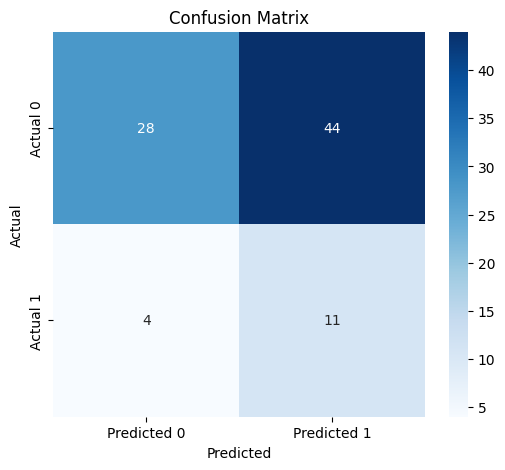

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Extracting True Positives, False Positives, True Negatives, False Negatives
tn, fp, fn, tp = cm.ravel()

# Compute Accuracy, Sensitivity, Specificity
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)  
specificity = tn / (tn + fp)

# Compute Precision
precision = tp / (tp + fp)

# Compute Recall 
recall = tp / (tp + fn)

# Compute F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("F1 Score:", f1)

# Print the results
print("Accuracy:", accuracy)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)
print("Precision:", precision)
print("Recall:", recall)
print("ROC AUC:", roc_auc)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## XGBoost

In [204]:
from xgboost import XGBClassifier


# Create an instance of the XGBoost model
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

# define the grid
grid_space = {

'n_estimators': [1000],
'colsample_bytree': [0.85, 0.9, 0.95], # Slightly varying around the best value
'learning_rate': [0.0015, 0.002, 0.0025], # Slightly varying around the best value
'max_depth': [1, 2], # Slightly varying around the best value
'min_child_weight': [6, 8, 10], # Slightly varying around the best value
'reg_alpha': [0.005, 0.01, 0.015], # Slightly varying around the best value
'reg_lambda': [1.5, 2, 2.5], # Slightly varying around the best value
'subsample': [0.9, 1.0] # Slightly varying around the best value

}


# Set up the grid search search
grid_search = GridSearchCV(estimator=xgb, param_grid=grid_space, cv=5, scoring='roc_auc', n_jobs=-1, verbose=True)

# Fit the model to the training data
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Get the best parameter values
best_parameters = grid_search.best_params_

# Get the best parameter AUS Score
best_score = grid_search.best_score_

# Print the best parameter values
print('Best hyperparameters are: '+str(best_parameters))
print('Best score is: '+str(best_score))

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Best hyperparameters are: {'colsample_bytree': 0.9, 'learning_rate': 0.0025, 'max_depth': 1, 'min_child_weight': 6, 'n_estimators': 1000, 'reg_alpha': 0.005, 'reg_lambda': 2, 'subsample': 1.0}
Best score is: 0.6010685748360167


In [205]:
from sklearn.model_selection import cross_val_predict

# Get out-of-fold predicted probabilities for the positive class
y_train_pred_proba_cv = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

In [206]:
from sklearn.metrics import roc_curve
import numpy as np

# Calculate ROC
fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_train, y_train_pred_proba_cv)

# Youden's J statistic
youden_j = tpr_cv - fpr_cv

# Find the optimal threshold
optimal_threshold = thresholds_cv[np.argmax(youden_j)]
print(f"Optimal threshold from training CV: {optimal_threshold}")

Optimal threshold from training CV: 0.1643490046262741


In [207]:
final_model = best_model.fit(X_train, y_train)

In [208]:
# Get predicted probabilities on the test set
y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Apply threshold from training CV
y_test_pred = (y_test_pred_proba > optimal_threshold).astype(int)

F1 Score: 0.25
Accuracy: 0.5172413793103449
Sensitivity (Recall): 0.4666666666666667
Specificity: 0.5277777777777778
Precision: 0.17073170731707318
Recall: 0.4666666666666667
ROC AUC: 0.5546296296296296


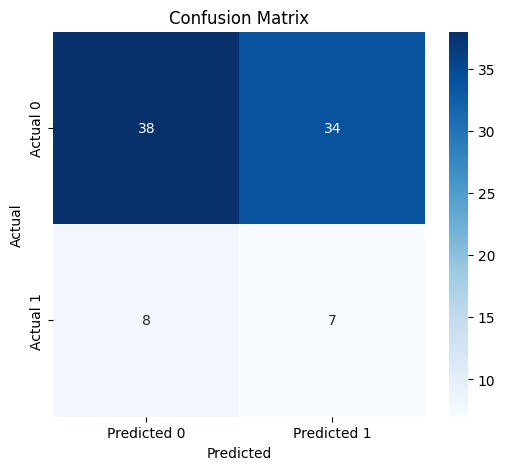

In [209]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Extracting True Positives, False Positives, True Negatives, False Negatives
tn, fp, fn, tp = cm.ravel()

# Compute Accuracy, Sensitivity, Specificity
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)  # Recall
specificity = tn / (tn + fp)

# Compute Precision
precision = tp / (tp + fp)

# Compute Recall 
recall = tp / (tp + fn)

# Compute F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("F1 Score:", f1)

# Print the results
print("Accuracy:", accuracy)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)
print("Precision:", precision)
print("Recall:", recall)
print("ROC AUC:", roc_auc)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## SMOTE XGBoost

In [182]:
# Define pipline
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=42))
])

# define the grid
grid_space = {
'clf__n_estimators': [500],
'clf__learning_rate': [0.01, 0.05, 0.1],
'clf__max_depth': [1, 3, 15],
'clf__min_child_weight': [1, 3, 5],
'clf__subsample': [0.8, 1.0],
'clf__colsample_bytree': [0.6, 0.8, 1.0],
'clf__reg_alpha': [0.1, 1],
'clf__reg_lambda': [1, 2]



}


# Create an instance of the logistic regression model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Set up the grid search
grid_search = GridSearchCV(estimator=pipeline, param_grid=grid_space, cv=5, scoring='roc_auc', n_jobs=-1, verbose=True)

# Fit the model to the training data
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Get the best parameter values
best_parameters = grid_search.best_params_

# Get the best parameter AUS Score
best_score = grid_search.best_score_

# Print the best parameter values
print('Best hyperparameters are: '+str(best_parameters))
print('Best score is: '+str(best_score))

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best hyperparameters are: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.01, 'clf__max_depth': 1, 'clf__min_child_weight': 1, 'clf__n_estimators': 500, 'clf__reg_alpha': 1, 'clf__reg_lambda': 2, 'clf__subsample': 1.0}
Best score is: 0.5592903995229577


In [183]:
# Get out-of-fold predicted probabilities for the positive class
y_train_pred_proba_cv = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

In [184]:
# Calculate ROC
fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_train, y_train_pred_proba_cv)

# Youden's J statistic
youden_j = tpr_cv - fpr_cv

# Find the optimal threshold
optimal_threshold = thresholds_cv[np.argmax(youden_j)]
print(f"Optimal threshold from training CV: {optimal_threshold}")

Optimal threshold from training CV: 0.4855605959892273


In [185]:
final_model = best_model.fit(X_train, y_train)

In [186]:
# Get predicted probabilities on the test set
y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Apply threshold from training CV
y_test_pred = (y_test_pred_proba > optimal_threshold).astype(int)

F1 Score: 0.31111111111111117
Accuracy: 0.6436781609195402
Sensitivity (Recall): 0.4666666666666667
Specificity: 0.6805555555555556
Precision: 0.23333333333333334
Recall: 0.4666666666666667
ROC AUC: 0.5976851851851852


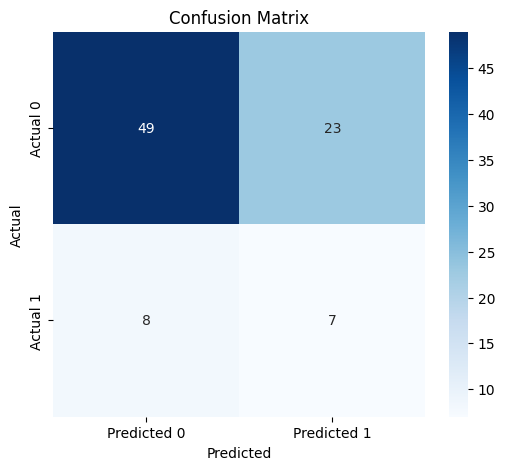

In [187]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Extracting True Positives, False Positives, True Negatives, False Negatives
tn, fp, fn, tp = cm.ravel()

# Compute Accuracy, Sensitivity, Specificity
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)  # Recall
specificity = tn / (tn + fp)

# Compute Precision
precision = tp / (tp + fp)

# Compute Recall (same as Sensitivity)
recall = tp / (tp + fn)

# Compute F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("F1 Score:", f1)

# Print the results
print("Accuracy:", accuracy)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)
print("Precision:", precision)
print("Recall:", recall)
print("ROC AUC:", roc_auc)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Down Sampled XGBoost

In [188]:
# Define the pipeline
pipeline = Pipeline([
    ('undersample', RandomUnderSampler(random_state=42)),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=42))
])

# Define the parameter grid
param_grid = {
    'clf__booster': ['gbtree'],
    'clf__learning_rate': [0.01, 0.1, 0.2, 0.3, 0.4],  # A range of values
    'clf__max_depth': [1, 3, 5, 7, 9, 20],  # Deeper trees to capture more complexity
    'clf__subsample': [0.5, 0.6, 0.8, 0.85, 0.9, 0.95, 1],  # Slightly smaller subsample values to reduce overfitting
    'clf__colsample_bytree': [0.8, 0.9, 1],  # Keep sampling range the same
    'clf__n_estimators': [100, 200, 300, 500],  # More trees to fine-tune the model
    'clf__objective': ['binary:logistic']

}

# Create an instance of GridSearchCV
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)


# Fit the model to the training data
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_

# Get the best parameter values
best_parameters = grid_search.best_params_

# Get the best parameter AUS Score
best_score = grid_search.best_score_

# Print the best parameter values
print('Best hyperparameters are: '+str(best_parameters))
print('Best score is: '+str(best_score))

Fitting 5 folds for each of 2520 candidates, totalling 12600 fits
Best hyperparameters are: {'clf__booster': 'gbtree', 'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.01, 'clf__max_depth': 9, 'clf__n_estimators': 100, 'clf__objective': 'binary:logistic', 'clf__subsample': 0.6}
Best score is: 0.5662540250447228


In [189]:
from sklearn.model_selection import cross_val_predict

# Get out-of-fold predicted probabilities for the positive class
y_train_pred_proba_cv = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

In [190]:
from sklearn.metrics import roc_curve
import numpy as np

# Calculate ROC
fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_train, y_train_pred_proba_cv)

# Youden's J statistic
youden_j = tpr_cv - fpr_cv

# Find the optimal threshold
optimal_threshold = thresholds_cv[np.argmax(youden_j)]
print(f"Optimal threshold from training CV: {optimal_threshold}")

Optimal threshold from training CV: 0.4967251420021057


In [191]:
final_model = best_model.fit(X_train, y_train)

In [192]:
# Get predicted probabilities on the test set
y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Apply threshold from training CV
y_test_pred = (y_test_pred_proba > optimal_threshold).astype(int)

F1 Score: 0.3548387096774194
Accuracy: 0.5402298850574713
Sensitivity (Recall): 0.7333333333333333
Specificity: 0.5
Precision: 0.23404255319148937
Recall: 0.7333333333333333
ROC AUC: 0.6351851851851851


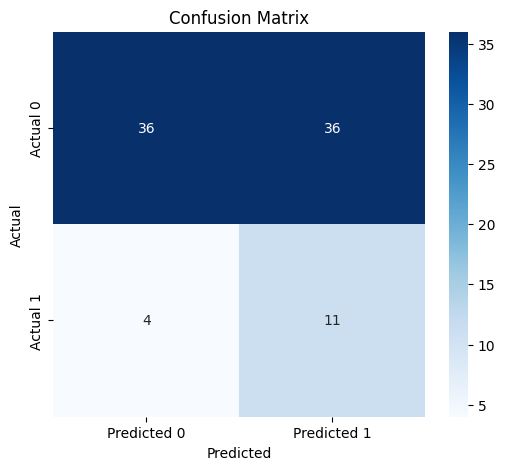

In [193]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Extracting True Positives, False Positives, True Negatives, False Negatives
tn, fp, fn, tp = cm.ravel()

# Compute Accuracy, Sensitivity, Specificity
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)  # Recall
specificity = tn / (tn + fp)

# Compute Precision
precision = tp / (tp + fp)

# Compute Recall (same as Sensitivity)
recall = tp / (tp + fn)

# Compute F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("F1 Score:", f1)

# Print the results
print("Accuracy:", accuracy)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)
print("Precision:", precision)
print("Recall:", recall)
print("ROC AUC:", roc_auc)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

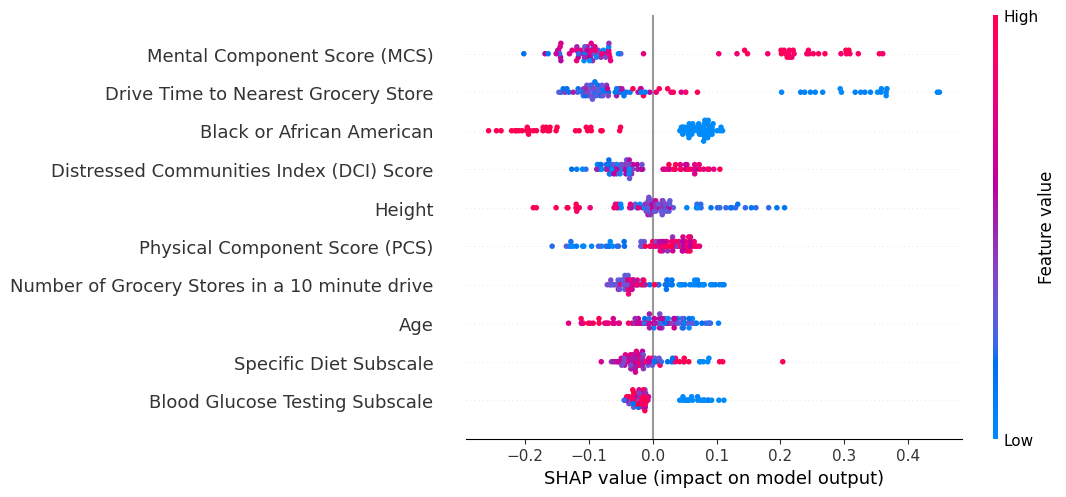

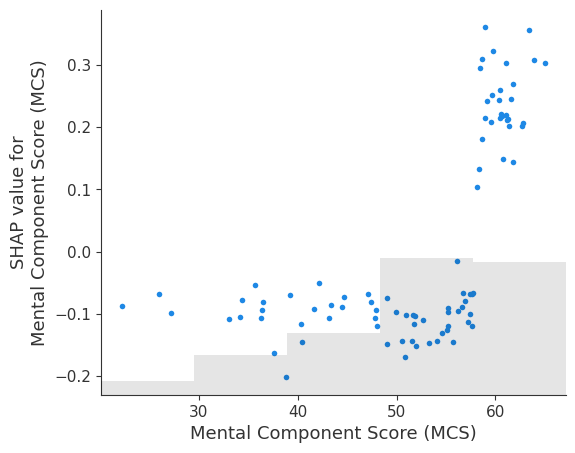

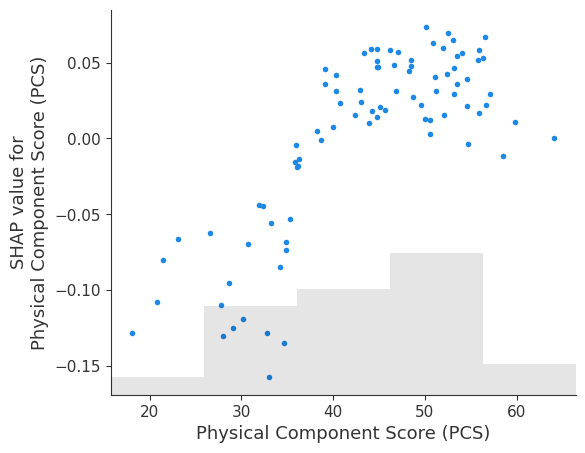

In [194]:
import shap

xgb_model = final_model.named_steps['clf']

explainer = shap.Explainer(xgb_model, model_output="raw")
shap_values = explainer(X_test)
explanation = explainer(X_test[:1000])

shap.plots.beeswarm(shap_values, max_display=10, group_remaining_features=False)
shap.plots.scatter(explanation[:, "Mental Component Score (MCS)"])
shap.plots.scatter(explanation[:, "Physical Component Score (PCS)"])

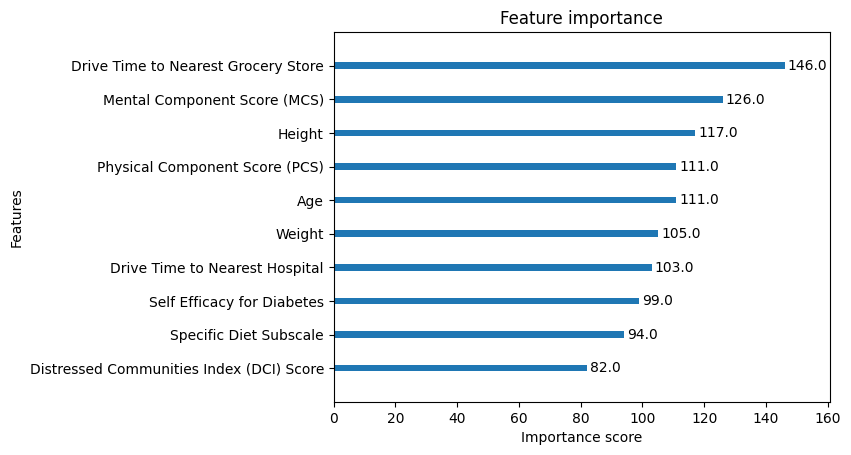

In [195]:
from xgboost import plot_importance

plot_importance(xgb_model, max_num_features=10)
plt.grid(False)
plt.show()

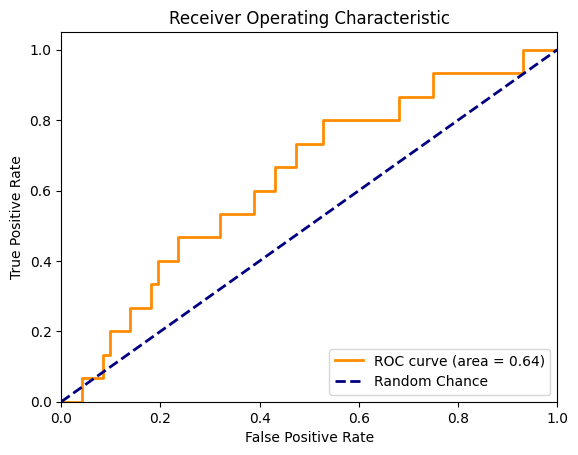

In [196]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


# Calculate the false positive rate and true positive rate
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)

# Calculate the AUC (Area Under the Curve)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = 0.64)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label = "Random Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## Cost sensitive xgboost

In [197]:
# Calculate the scale_pos_weight
neg_class = sum(y_train == 0)
pos_class = sum(y_train == 1)
scale_pos_weight = neg_class / pos_class


pipeline = Pipeline([
    ('clf', XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=scale_pos_weight
    ))
])
# Define the grid


grid_space = {
    
'clf__max_depth': [1, 2],
'clf__learning_rate': [0.0005, 0.001, 0.005],
'clf__min_child_weight': [8, 10, 12],
'clf__subsample': [0.8, 1.0],
'clf__colsample_bytree': [0.6, 0.8, 1.0],
'clf__reg_alpha': [0.005, 0.01, 0.05],
'clf__reg_lambda': [1, 2, 3],
'clf__n_estimators': [1000]

}



# Set up the grid search
grid_search = GridSearchCV(estimator=pipeline, param_grid=grid_space, cv=5, scoring='roc_auc', n_jobs=-1, verbose=True)

# Fit the model to the training data
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Get the best parameter values
best_parameters = grid_search.best_params_

# Get the best parameter AUC Score
best_score = grid_search.best_score_

# Print the best parameter values
print('Best hyperparameters are: ' + str(best_parameters))
print('Best score is: ' + str(best_score))

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Best hyperparameters are: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.005, 'clf__max_depth': 1, 'clf__min_child_weight': 12, 'clf__n_estimators': 1000, 'clf__reg_alpha': 0.005, 'clf__reg_lambda': 1, 'clf__subsample': 1.0}
Best score is: 0.5963995229576625


In [198]:
# Get out-of-fold predicted probabilities for the positive class
y_train_pred_proba_cv = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

In [199]:

# Calculate ROC
fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_train, y_train_pred_proba_cv)

# Youden's J statistic
youden_j = tpr_cv - fpr_cv

# Find the optimal threshold
optimal_threshold = thresholds_cv[np.argmax(youden_j)]
print(f"Optimal threshold from training CV: {optimal_threshold}")

Optimal threshold from training CV: 0.4684399962425232


In [200]:
final_model = best_model.fit(X_train, y_train)

In [201]:
# Get predicted probabilities on the test set
y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Apply threshold from training CV
y_test_pred = (y_test_pred_proba > optimal_threshold).astype(int)

F1 Score: 0.25
Accuracy: 0.5172413793103449
Sensitivity (Recall): 0.4666666666666667
Specificity: 0.5277777777777778
Precision: 0.17073170731707318
Recall: 0.4666666666666667
ROC AUC: 0.5430555555555556


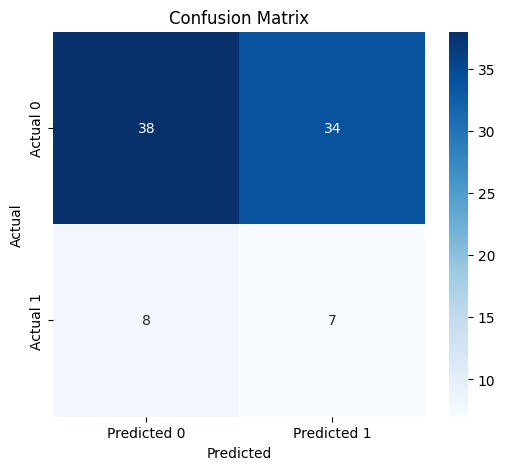

In [202]:

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Extracting True Positives, False Positives, True Negatives, False Negatives
tn, fp, fn, tp = cm.ravel()

# Compute Accuracy, Sensitivity, Specificity
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)  # Recall
specificity = tn / (tn + fp)

# Compute Precision
precision = tp / (tp + fp)

# Compute Recall (same as Sensitivity)
recall = tp / (tp + fn)

# Compute F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("F1 Score:", f1)

# Print the results
print("Accuracy:", accuracy)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)
print("Precision:", precision)
print("Recall:", recall)
print("ROC AUC:", roc_auc)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Simulating Random Prediction

In [203]:
from sklearn.dummy import DummyClassifier

# Create a DummyClassifier with the 'uniform' strategy to make random predictions
dummy_clf = DummyClassifier(strategy='uniform', random_state=42)
dummy_clf.fit(X_train, y_train)

y_pred = dummy_clf.predict(X_test)
y_pred_proba = dummy_clf.predict_proba(X_test)[:, 1]

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, )

# Compute sensitivity, specificity, precision, recall, and F1 score
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
recall = sensitivity
f1_score = 2 * (precision * recall) / (precision + recall)
accuracy = (tp + tn) / (tp + fn + fp + tn)

# Compute area under the ROC curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Print the results
print("Accuracy", accuracy)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)
print("Area under ROC Curve:", roc_auc)
print("confusion matrix:", cm)

Accuracy 0.47126436781609193
Sensitivity: 0.4666666666666667
Specificity: 0.4722222222222222
Precision: 0.15555555555555556
Recall: 0.4666666666666667
F1 Score: 0.23333333333333334
Area under ROC Curve: 0.5
confusion matrix: [[34 38]
 [ 8  7]]
